# BottleNeck — Analyse du stock et des ventes

**Version 2 — livrable révisé** · Mano Aroul · 24 août 2026
Période analysée : 1ᵉʳ au 31 octobre · Extraction des stocks au 31 octobre

---

## Ce que cette version corrige

Ce notebook reprend l'analyse livrée au comité de direction et corrige trois erreurs de calcul
qui ont produit des recommandations erronées. Les corrections ne relèvent pas du détail : deux
d'entre elles inversent la conclusion métier.

| Indicateur | Version livrée au CODIR | Version corrigée | Conséquence |
|---|---|---|---|
| Articles à plus de 12 mois de stock | 639 — soit 77 % du catalogue | **24** | La recommandation de brader 639 références portait sur un catalogue dont la rotation médiane est de 2,4 mois |
| Concentration du chiffre d'affaires | « forte concentration sur un petit nombre de produits » | **Dispersion** — 435 articles font 80 % du CA, soit 63 % des références vendues | Le problème est une longue traîne, pas une dépendance à quelques best-sellers |
| Taux de marge moyen | 47,3 % | **36,8 %** de taux de marque HT | Le champagne n'est pas peu rentable, il est vendu quasiment à prix coûtant |

Chaque correction est démontrée dans la section correspondante, avec le calcul fautif et le
calcul juste exécutés côte à côte.

## Démarche

1. Contrôler la qualité des sources avant toute analyse, et tracer chaque correction
2. Consolider les trois extractions avec un contrôle explicite de non-duplication
3. Vérifier les hypothèses statistiques **avant** d'appliquer une méthode qui en dépend
4. Comparer les méthodes de détection d'erreurs sur une vérité terrain plutôt que sur une intuition
5. Recalculer les indicateurs de gestion et mesurer l'écart avec la version précédente
6. Valider la table finale contre un schéma qui rend l'absurde impossible à livrer

La logique de calcul est isolée dans `src/pipeline.py` et couverte par 19 tests unitaires (32 avec ceux du filtrage de veille).
Ce notebook orchestre et commente ; il ne calcule pas.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pipeline as pl
import viz
from schema import appliquer_quarantaine, valider

viz.appliquer_theme()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RNG = np.random.default_rng(42)   # graine fixée : toute exécution redonne les mêmes chiffres
FIGS = Path.cwd() / "figures"
FIGS.mkdir(exist_ok=True)

print(f"pandas {pd.__version__} · numpy {np.__version__}")

pandas 3.0.2 · numpy 2.4.4


---

# 1. Les sources et leur qualité

Trois extractions, trois systèmes qui ne se parlent pas. L'ERP porte les prix et les stocks,
l'export WordPress porte les ventes, la table de liaison fait le pont entre deux systèmes de
référencement incompatibles.

Le contrôle qualité précède l'analyse et non l'inverse. Chaque correction est consignée dans un
registre : Nicolas demande explicitement à comprendre les erreurs rencontrées, ce qu'une
correction silencieuse ne permet pas.

In [2]:
sources = pl.charger_sources()
for nom, tbl in sources.items():
    print(f"{nom:8s} : {tbl.shape[0]:>5} lignes × {tbl.shape[1]:>2} colonnes")

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


erp      :   825 lignes ×  6 colonnes
web      :  1513 lignes × 29 colonnes
liaison  :   825 lignes ×  2 colonnes


/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
erp_propre, registre = pl.nettoyer_erp(sources["erp"])
registre

,product_id,champ,anomalie,avant,apres,traitement
0,4233,price,prix négatif,-20.0,20.0,valeur absolue — erreur de signe à la saisie
1,5017,price,prix négatif,-8.0,8.0,valeur absolue — erreur de signe à la saisie
2,6594,price,prix négatif,-9.1,9.1,valeur absolue — erreur de signe à la saisie
3,4973,stock_quantity,stock négatif,-10,0,remis à zéro — un stock physique ne peut être ...
4,5700,stock_quantity,stock négatif,-1,0,remis à zéro — un stock physique ne peut être ...
5,4039,stock_status,statut incohérent avec la quantité,outofstock,recalculé,dérivé de stock_quantity — le statut est redon...
6,4885,stock_status,statut incohérent avec la quantité,instock,recalculé,dérivé de stock_quantity — le statut est redon...


Sept anomalies corrigées dans l'ERP, de trois natures distinctes.

Les **trois prix négatifs** sont traités en valeur absolue. L'hypothèse retenue est celle d'une
erreur de signe à la saisie, et elle mérite d'être explicitée parce qu'elle n'est pas neutre :
si ces prix résultaient d'un avoir ou d'une remise mal enregistrée, la valeur absolue serait
fausse et il faudrait les écarter. La cohérence des prix d'achat associés soutient l'hypothèse
de l'erreur de signe, sans la démontrer. **À confirmer auprès de l'équipe de saisie.**

Les **deux stocks négatifs** sont remis à zéro : un stock physique ne peut pas être négatif.

Les **deux statuts incohérents** révèlent un défaut de conception plutôt qu'une erreur de saisie.
`stock_status` est intégralement déductible de `stock_quantity` ; le stocker séparément crée une
source de divergence sans apporter d'information. La recommandation qui en découle figure en
section 9 : supprimer le champ et le calculer à l'affichage.

In [4]:
web_propre, journal_web = pl.nettoyer_web(sources["web"])
pd.Series(journal_web).to_frame("valeur")

,valeur
lignes_export,1513
pieces_jointes_ecartees,714
fiches_produit,716
fiches_sans_sku_ecartees,2
produits_exploitables,714


**Une rectification par rapport à la version précédente.** La présentation au CODIR annonçait
« 714 doublons — des pièces jointes qui reprennent le même code article » et « 83 lignes vides ».

Les deux qualifications sont inexactes. Les 714 lignes en question ne sont pas des doublons mais
des enregistrements de type `attachment` : dans WordPress, chaque image de fiche produit est une
ligne de la table `posts`. Ce ne sont pas des produits en double, ce sont des objets d'une autre
nature, et l'export les mélange aux produits. Quant aux lignes sans SKU, elles ne sont que **2**
parmi les fiches produit — les 83 autres appartenaient déjà aux pièces jointes et étaient donc
comptées deux fois.

La correction ne change pas le résultat du filtrage, qui restait bon. Elle change ce qu'on
raconte à l'équipe : le problème n'est pas que le site génère des doublons, c'est que l'export
ne filtre pas par type de contenu.

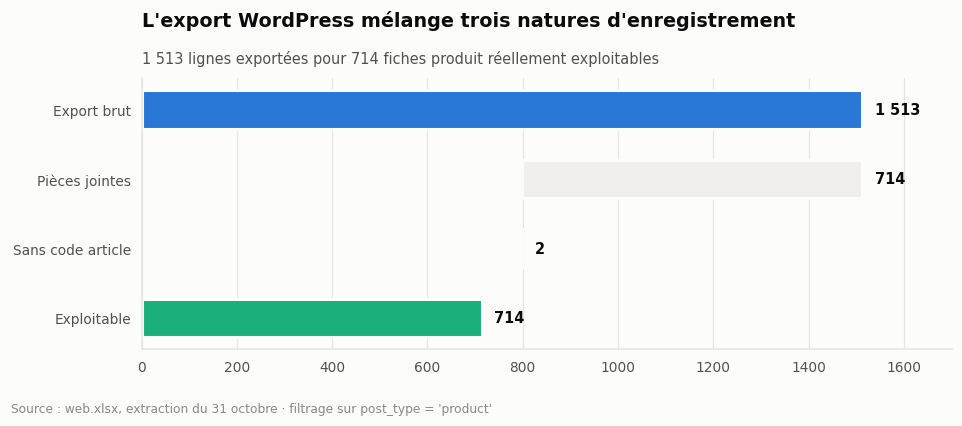

In [5]:
fig, ax = viz.cadre(9.5, 3.2)

etapes = ["Export brut", "Pièces jointes", "Sans code article", "Exploitable"]
valeurs = [journal_web["lignes_export"], -journal_web["pieces_jointes_ecartees"],
           -journal_web["fiches_sans_sku_ecartees"], journal_web["produits_exploitables"]]

bases = [0]
for v in valeurs[1:-1]:
    bases.append(bases[-1] + (valeurs[0] if len(bases) == 1 else 0))
bases = [0, journal_web["lignes_export"] + valeurs[1], journal_web["lignes_export"] + valeurs[1] + valeurs[2], 0]
hauteurs = [journal_web["lignes_export"], -valeurs[1], -valeurs[2], journal_web["produits_exploitables"]]
couleurs = [viz.SERIE[0], viz.NEUTRE, viz.NEUTRE, viz.SERIE[2]]

for i, (b, h, c) in enumerate(zip(bases, hauteurs, couleurs)):
    ax.barh(i, h, left=b, height=0.55, color=c, edgecolor=viz.SURFACE, linewidth=2)
    ax.annotate(f"{h:,}".replace(",", " "), xy=(b + h, i), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9.5,
                fontweight="semibold", color=viz.TEXTE)

ax.set_yticks(range(4)); ax.set_yticklabels(etapes)
ax.invert_yaxis(); viz.grille_x(ax)
ax.set_xlim(0, 1700)
ax.set_title("L'export WordPress mélange trois natures d'enregistrement")
viz.sous_titre(ax, "1 513 lignes exportées pour 714 fiches produit réellement exploitables")
viz.source(fig, "Source : web.xlsx, extraction du 31 octobre · filtrage sur post_type = 'product'")
plt.savefig(FIGS / "01_composition_export_web.png"); plt.show()

---

# 2. Consolidation des trois sources

Deux jointures successives : l'ERP porte la référence, la table de liaison apporte
l'identifiant web, l'export web apporte les ventes.

Le point de vigilance est la **duplication silencieuse**. Si une clé apparaît deux fois du côté
droit d'une jointure, pandas produit deux lignes là où il en attendait une, et tous les agrégats
qui suivent sont gonflés sans qu'aucun message d'erreur ne le signale. Le paramètre `validate=`
transforme ce risque en exception : c'est la ligne de défense absente de la version précédente.

In [6]:
table, couverture = pl.consolider(erp_propre, web_propre, sources["liaison"])
pd.Series(couverture).to_frame("valeur")

,valeur
articles_erp,825.0000
sans_identifiant_web,91.0000
sans_correspondance_web,111.0000
articles_analysables,714.0000
taux_couverture,0.8655


**La couverture est de 86,6 %, et ce chiffre n'était pas quantifié dans la version précédente.**

111 articles de l'ERP n'ont aucune correspondance sur le site : 91 n'ont pas d'identifiant web
dans la table de liaison, 20 en ont un qui ne correspond à aucune fiche. Ces articles sortent
mécaniquement de tout calcul de chiffre d'affaires, mais **ils portent 21 300 € de stock**.

Ce n'est pas nécessairement une anomalie — un article vendu exclusivement en boutique n'a pas
vocation à figurer sur le site. C'est en revanche une information à remonter, parce qu'elle
détermine si le CA calculé couvre l'activité réelle ou seulement sa partie web. Le choix retenu
ici est de conserver ces articles dans la table, avec un CA nul et non manquant, afin qu'ils
restent visibles dans les analyses de stock.

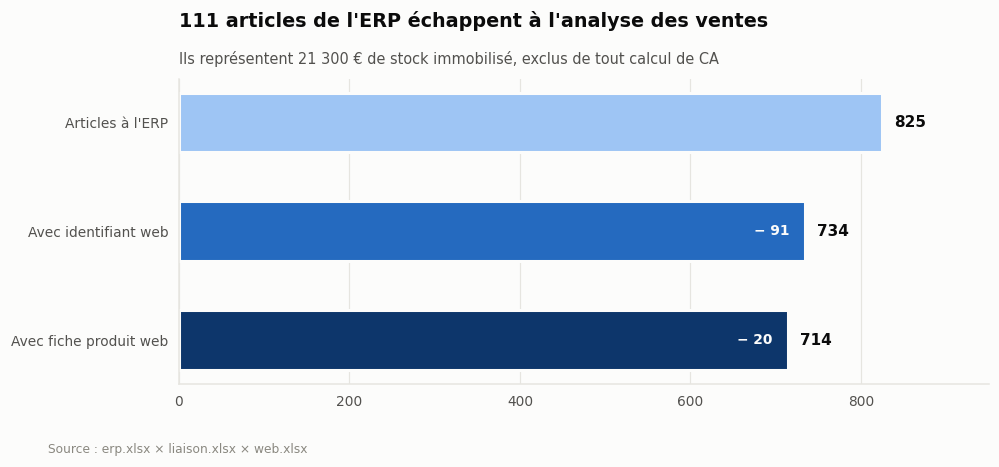

In [7]:
fig, ax = viz.cadre(9.5, 3.6)

niveaux = ["Articles à l'ERP", "Avec identifiant web", "Avec fiche produit web"]
vals = [couverture["articles_erp"],
        couverture["articles_erp"] - couverture["sans_identifiant_web"],
        couverture["articles_analysables"]]
couleurs = viz.degrade(3)

barres = ax.barh(niveaux, vals, height=0.55, color=couleurs, edgecolor=viz.SURFACE, linewidth=2)
for i, (v, n) in enumerate(zip(vals, niveaux)):
    ax.annotate(f"{v}", xy=(v, i), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=10, fontweight="semibold", color=viz.TEXTE)
    if i > 0:
        perdu = vals[i - 1] - v
        ax.annotate(f"− {perdu}", xy=(v, i), xytext=(-10, 0), textcoords="offset points",
                    va="center", ha="right", fontsize=9, color=viz.SURFACE, fontweight="semibold")

ax.invert_yaxis(); viz.grille_x(ax); ax.set_xlim(0, 950)
ax.set_title("111 articles de l'ERP échappent à l'analyse des ventes")
viz.sous_titre(ax, "Ils représentent 21 300 € de stock immobilisé, exclus de tout calcul de CA")
viz.source(fig, "Source : erp.xlsx × liaison.xlsx × web.xlsx")
plt.savefig(FIGS / "02_couverture_jointure.png"); plt.show()

In [8]:
table["prix_ht"] = pl.prix_ht(table["price"])
table["ca_ht"] = pl.chiffre_affaires_ht(table["price"], table["total_sales"])
table["taux_marque"] = pl.taux_de_marque(table["prix_ht"], table["purchase_price"])
table["taux_marge"] = pl.taux_de_marge(table["prix_ht"], table["purchase_price"])
table["mois_stock"] = pl.mois_de_stock(table["stock_quantity"], table["total_sales"])
table["valo_stock"] = table["stock_quantity"] * table["purchase_price"]
table["prix_suspect"] = pl.detecter_erreurs_prix(table["price"], table["purchase_price"])

vendus = table[table["sku"].notna()].copy()
print(f"Table consolidée : {len(table)} articles, dont {len(vendus)} présents sur le site")

Table consolidée : 825 articles, dont 714 présents sur le site


---

# 3. La distribution des prix, et pourquoi le Z-score ne pouvait pas fonctionner

La version précédente appliquait un Z-score au seuil de 3 pour détecter les prix aberrants.
Le Z-score mesure un écart à la moyenne exprimé en écarts-types, et le seuil de 3 tire son sens
d'une propriété de la loi normale : sous cette loi, 99,7 % des observations s'y trouvent
comprises. Hors de cette hypothèse, le seuil ne veut plus rien dire de particulier.

La question n'est donc pas de savoir si le Z-score a trouvé quelque chose, mais si la
distribution des prix autorisait à l'employer. Elle se vérifie en trois lignes, et la version
précédente ne l'a pas fait.

In [9]:
prix = vendus["prix_ht"].dropna()

sw = stats.shapiro(prix.sample(500, random_state=42))
sw_log = stats.shapiro(np.log(prix).sample(500, random_state=42))

diagnostic = pd.DataFrame({
    "Prix HT": [prix.mean(), prix.median(), stats.skew(prix), stats.kurtosis(prix), sw.pvalue],
    "log(Prix HT)": [np.log(prix).mean(), np.log(prix).median(),
                     stats.skew(np.log(prix)), stats.kurtosis(np.log(prix)), sw_log.pvalue],
}, index=["Moyenne", "Médiane", "Asymétrie (skewness)", "Aplatissement (kurtosis)",
          "Shapiro-Wilk — p-value"])
diagnostic.style.format({"Prix HT": "{:.4g}", "log(Prix HT)": "{:.4g}"})

,Prix HT,log(Prix HT)
Moyenne,26.94,3.022
Médiane,19.54,2.973
Asymétrie (skewness),2.597,0.2858
Aplatissement (kurtosis),10.29,-0.4246
Shapiro-Wilk — p-value,5.157e-27,0.0001536


**L'hypothèse de normalité est rejetée sans ambiguïté.** L'asymétrie atteint 2,64 là où une loi
normale vaut 0, l'aplatissement 10,8 là où elle vaut 0, et le test de Shapiro-Wilk retourne une
p-value de l'ordre de 10⁻²⁴. Il ne s'agit pas d'un écart limite qu'on pourrait négliger.

Le passage au logarithme ramène l'asymétrie à 0,24 : les prix suivent approximativement une loi
**log-normale**, ce qui est le comportement attendu d'un catalogue où coexistent des vins
d'entrée de gamme et des grands crus. Cette observation ne sauve pas pour autant la méthode,
comme la section suivante le montre.

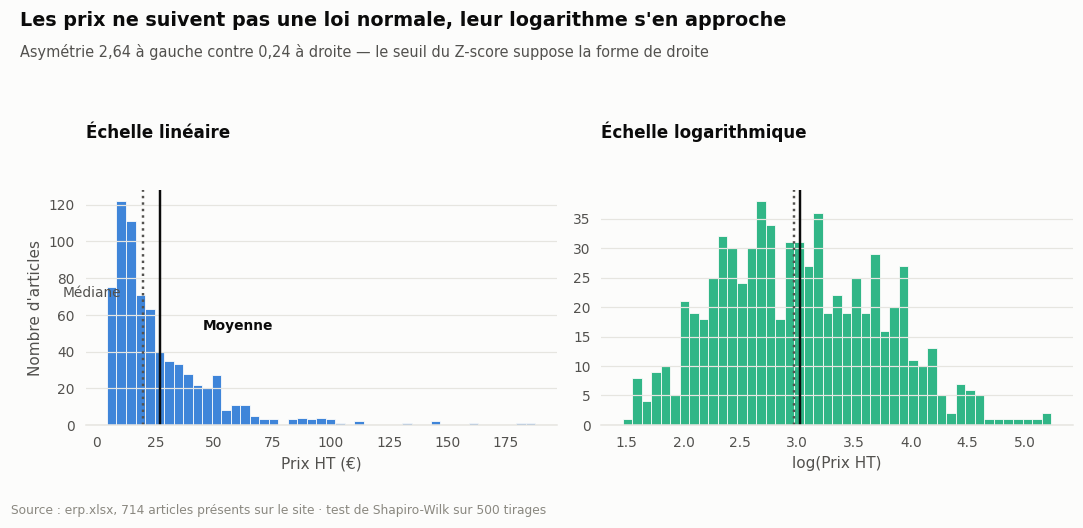

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.8))

for ax, donnees, titre, couleur in [
    (axes[0], prix, "Échelle linéaire", viz.SERIE[0]),
    (axes[1], np.log(prix), "Échelle logarithmique", viz.SERIE[2]),
]:
    ax.hist(donnees, bins=45, color=couleur, edgecolor=viz.SURFACE, linewidth=0.6, alpha=0.9)
    ax.axvline(donnees.mean(), color=viz.TEXTE, linewidth=1.6, linestyle="-")
    ax.axvline(donnees.median(), color=viz.TEXTE_SECONDAIRE, linewidth=1.6, linestyle=":")
    ax.set_title(titre, fontsize=11)
    ax.set_ylabel("Nombre d'articles" if ax is axes[0] else "")
    ax.spines["left"].set_visible(False)

axes[0].annotate("Moyenne", xy=(prix.mean(), 0), xytext=(28, 62),
                 textcoords="offset points", fontsize=9, color=viz.TEXTE, fontweight="semibold")
axes[0].annotate("Médiane", xy=(prix.median(), 0), xytext=(-52, 84),
                 textcoords="offset points", fontsize=9, color=viz.TEXTE_SECONDAIRE)
axes[0].set_xlabel("Prix HT (€)"); axes[1].set_xlabel("log(Prix HT)")

fig.suptitle("Les prix ne suivent pas une loi normale, leur logarithme s'en approche",
             x=0.008, ha="left", fontsize=12.5, fontweight="semibold", y=1.14)
fig.text(0.008, 1.03, "Asymétrie 2,64 à gauche contre 0,24 à droite — le seuil du Z-score suppose la forme de droite",
         ha="left", fontsize=9.5, color=viz.TEXTE_SECONDAIRE)
viz.source(fig, "Source : erp.xlsx, 714 articles présents sur le site · test de Shapiro-Wilk sur 500 tirages")
plt.tight_layout(); plt.savefig(FIGS / "03_distribution_prix.png"); plt.show()

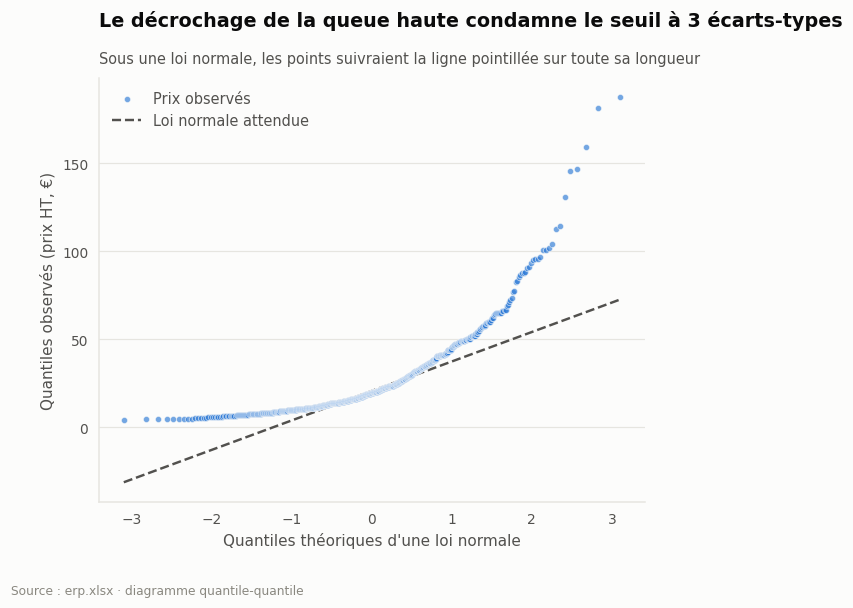

In [11]:
fig, ax = viz.cadre(6.4, 5.0)

theoriques, ordonnees = stats.probplot(prix, dist="norm", fit=False)
ax.scatter(theoriques, ordonnees, s=16, color=viz.SERIE[0], alpha=0.65,
           edgecolor=viz.SURFACE, linewidth=0.5, zorder=3, label="Prix observés")

lim = [theoriques.min(), theoriques.max()]
pente, ordonnee = np.polyfit(theoriques[len(theoriques)//4:3*len(theoriques)//4],
                             ordonnees[len(ordonnees)//4:3*len(ordonnees)//4], 1)
ax.plot(lim, [pente * x + ordonnee for x in lim], color=viz.TEXTE_SECONDAIRE,
        linewidth=1.6, linestyle="--", zorder=2, label="Loi normale attendue")

ax.set_xlabel("Quantiles théoriques d'une loi normale")
ax.set_ylabel("Quantiles observés (prix HT, €)")
ax.legend(loc="upper left")
ax.set_title("Le décrochage de la queue haute condamne le seuil à 3 écarts-types")
viz.sous_titre(ax, "Sous une loi normale, les points suivraient la ligne pointillée sur toute sa longueur")
viz.source(fig, "Source : erp.xlsx · diagramme quantile-quantile")
plt.savefig(FIGS / "04_qqplot_prix.png"); plt.show()

Le diagramme quantile-quantile rend le diagnostic visuel. Les points suivent correctement la
droite dans la partie centrale, puis décrochent nettement vers le haut à partir du deuxième
quantile théorique. Ce décrochage est précisément la zone où le Z-score va chercher ses valeurs
aberrantes — c'est-à-dire la zone où le modèle sous-jacent ne décrit plus les données.

Ce que le Z-score a détecté n'est donc pas un ensemble d'erreurs, c'est la queue haute d'une
distribution asymétrique. La conclusion de la version précédente — « ce sont des grands crus
légitimes, il n'y a pas d'erreur de prix » — était exacte, mais la méthode ne pouvait pas
produire d'autre réponse.

---

# 4. Détecter des valeurs erronées plutôt que des valeurs extrêmes

C'est le cœur méthodologique de cette révision.

Nicolas demande de « vérifier les erreurs de saisie en détectant des potentielles valeurs
aberrantes ». La formulation assimile les deux notions ; elles ne se recouvrent pas.

> Un Château Margaux à 225 € TTC est **extrême et juste**.
> Un vin d'entrée de gamme saisi à 52 € au lieu de 5,20 € est **erroné et parfaitement banal** —
> il se situe au 88ᵉ centile du catalogue, hors d'atteinte de tout seuil de détection.

Une erreur de saisie n'est pas statistiquement isolée, elle est **métier-incohérente**.
L'information qui la trahit — un marchand de vin ne vend jamais sous son prix d'achat ni au-delà
de trois fois celui-ci — ne se trouve pas dans la distribution des prix. Elle se trouve dans le
rapport entre le prix de vente et le prix d'achat, que la version précédente n'a jamais examiné.

## Protocole de comparaison

Départager des méthodes suppose une vérité terrain, qui n'existe pas ici. Elle est construite
par **injection contrôlée** : 40 erreurs de saisie réalistes sont introduites dans le catalogue
propre, et chaque méthode est jugée sur sa capacité à les retrouver. Le protocole est répété sur
20 graines, parce qu'un tirage unique ne permettrait pas de distinguer un écart réel d'une
fluctuation d'échantillonnage.

Quatre types d'erreurs, choisis pour leur fréquence en saisie ERP :

| Type | Exemple | Visible sur le prix seul ? |
|---|---|---|
| Virgule décalée vers le haut | 5,20 → 52,00 | Parfois |
| Virgule décalée vers le bas | 52,00 → 5,20 | Non — valeur basse banale |
| Inversion de chiffres | 24,30 → 42,30 | Non — écart trop faible |
| Colonne confondue | prix de vente = prix d'achat | Non — valeur plausible |

Le code du protocole est dans `src/benchmark_outliers.py`.

In [12]:
sys.path.insert(0, str(Path.cwd().parent / "src"))
from benchmark_outliers import main as lancer_benchmark, rappel_par_type

resultats, _ = lancer_benchmark(n_graines=20)
resultats[["Méthode", "Precision_moy", "Rappel_moy", "F1_moy", "FP_moy"]].rename(columns={
    "Precision_moy": "Précision", "Rappel_moy": "Rappel",
    "F1_moy": "F1", "FP_moy": "Faux positifs"})

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Méthode,Précision,Rappel,F1,Faux positifs
0,Règle métier prix/prix d'achat,0.974,0.904,0.937,0.95
1,Hybride règle + Isolation Forest,0.755,0.909,0.824,11.85
2,Local Outlier Factor (multivarié),0.729,0.656,0.691,9.75
3,Isolation Forest (multivarié),0.671,0.604,0.636,11.85
4,Z-score sur log(prix),1.000,0.204,0.336,0.00
5,IQR sur prix (méthode P6),0.275,0.262,0.268,27.10
6,Z-score sur prix (méthode P6),0.759,0.148,0.241,2.35


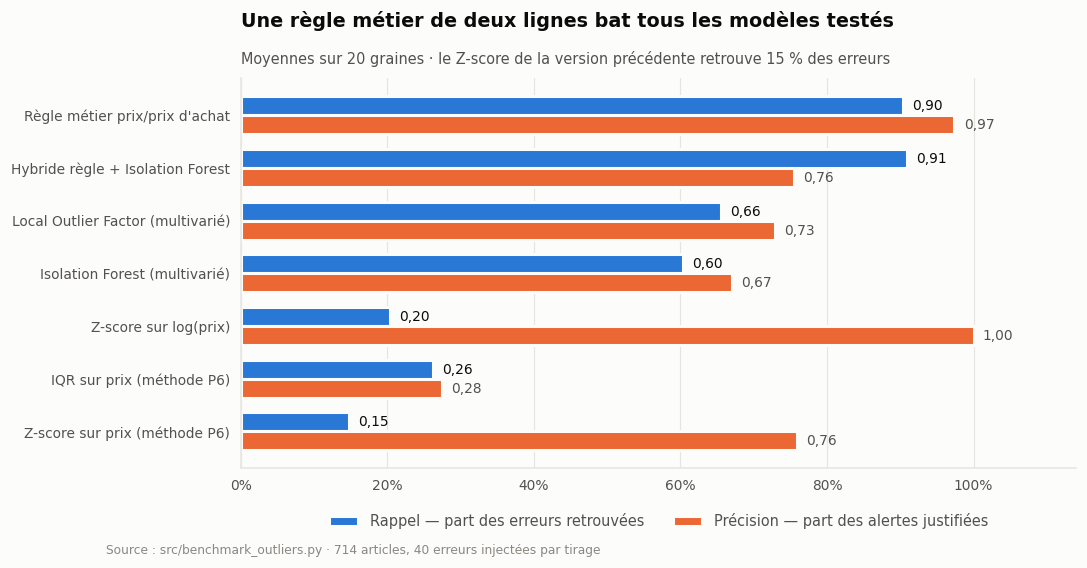

In [13]:
fig, ax = viz.cadre(9.8, 4.6)

r = resultats.sort_values("F1_moy")
y = np.arange(len(r)); h = 0.36

ax.barh(y + h/2, r["Rappel_moy"], height=h, color=viz.SERIE[0],
        edgecolor=viz.SURFACE, linewidth=2, label="Rappel — part des erreurs retrouvées")
ax.barh(y - h/2, r["Precision_moy"], height=h, color=viz.SERIE[1],
        edgecolor=viz.SURFACE, linewidth=2, label="Précision — part des alertes justifiées")

for i, (rap, pre) in enumerate(zip(r["Rappel_moy"], r["Precision_moy"])):
    ax.annotate(f"{rap:.2f}".replace(".", ","), xy=(rap, i + h/2), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=viz.TEXTE)
    ax.annotate(f"{pre:.2f}".replace(".", ","), xy=(pre, i - h/2), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=viz.TEXTE_SECONDAIRE)

ax.set_yticks(y); ax.set_yticklabels(r["Méthode"])
ax.set_xlim(0, 1.14); viz.grille_x(ax)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, borderaxespad=0)
ax.set_title("Une règle métier de deux lignes bat tous les modèles testés")
viz.sous_titre(ax, "Moyennes sur 20 graines · le Z-score de la version précédente retrouve 15 % des erreurs")
viz.source(fig, "Source : src/benchmark_outliers.py · 714 articles, 40 erreurs injectées par tirage")
plt.savefig(FIGS / "05_benchmark_methodes.png"); plt.show()

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


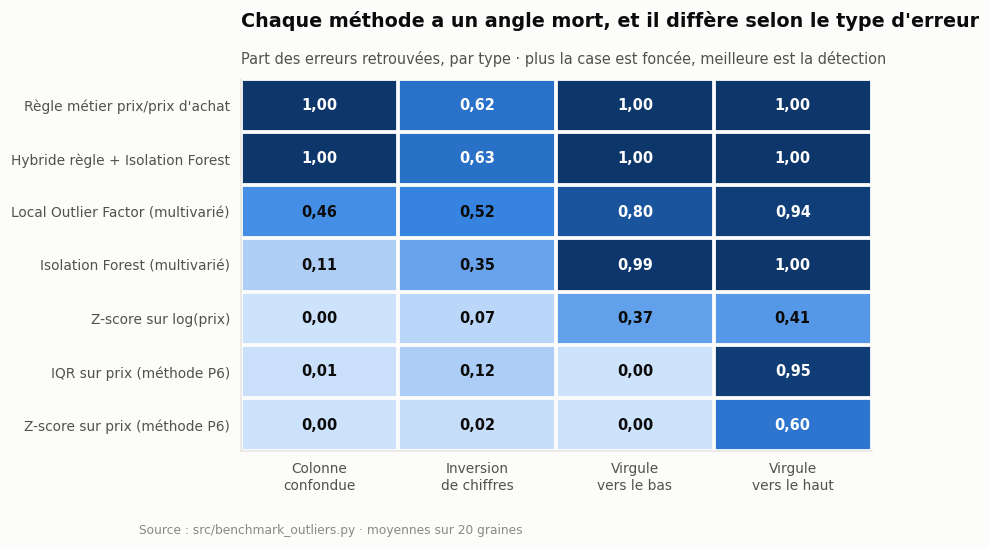

In [14]:
mat = rappel_par_type(n_graines=20)
ordre = ["Règle métier prix/prix d'achat", "Hybride règle + Isolation Forest",
         "Local Outlier Factor (multivarié)", "Isolation Forest (multivarié)",
         "Z-score sur log(prix)", "IQR sur prix (méthode P6)", "Z-score sur prix (méthode P6)"]
mat = mat.reindex([m for m in ordre if m in mat.index])
libelles = {"colonne_confondue": "Colonne\nconfondue", "inversion": "Inversion\nde chiffres",
            "virgule_bas": "Virgule\nvers le bas", "virgule_haut": "Virgule\nvers le haut"}
mat = mat[["colonne_confondue", "inversion", "virgule_bas", "virgule_haut"]]

fig, ax = viz.cadre(7.4, 4.4)
from matplotlib.colors import LinearSegmentedColormap
rampe = LinearSegmentedColormap.from_list("bleu", viz.RAMPE_BLEUE)

im = ax.imshow(mat.values, cmap=rampe, vmin=0, vmax=1, aspect="auto")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        ax.text(j, i, f"{v:.2f}".replace(".", ","), ha="center", va="center", fontsize=9.5,
                fontweight="semibold", color="#ffffff" if v > 0.55 else viz.TEXTE)

ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels([libelles[c] for c in mat.columns], fontsize=9)
ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index, fontsize=9)
ax.set_xticks(np.arange(-.5, mat.shape[1]), minor=True)
ax.set_yticks(np.arange(-.5, mat.shape[0]), minor=True)
ax.grid(which="minor", color=viz.SURFACE, linewidth=2.5); ax.grid(False, which="major")
ax.tick_params(which="minor", length=0)
ax.set_title("Chaque méthode a un angle mort, et il diffère selon le type d'erreur")
viz.sous_titre(ax, "Part des erreurs retrouvées, par type · plus la case est foncée, meilleure est la détection")
viz.source(fig, "Source : src/benchmark_outliers.py · moyennes sur 20 graines")
plt.savefig(FIGS / "06_rappel_par_type.png"); plt.show()

## Ce que le tableau croisé révèle, et que le score global masquait

Le F1 est une moyenne harmonique : il résume, donc il dissimule. Décomposé par type d'erreur, il
apparaît que **chaque méthode a un angle mort, et que ces angles morts sont différents**.

Le Z-score de la version précédente retrouve 60 % des virgules décalées vers le haut — les seules
erreurs qui produisent une valeur haute — et **rien d'autre**. Zéro sur les colonnes confondues,
0,02 sur les inversions, zéro sur les virgules vers le bas. Ce n'est pas une méthode faible,
c'est une méthode qui répond à une autre question.

**Un incident de conception, conservé ici parce qu'il est instructif.** La première version de la
règle métier était bornée à `ratio < 1,0`. Elle ratait **100 %** des erreurs de type « colonne
confondue » : recopier le prix d'achat dans le prix de vente produit un ratio exactement égal à 1,
juste en dehors de l'inégalité stricte. Le F1 global affichait alors 0,768, ce qui se lit comme
une performance honorable. Un seul caractère de différence — `<` au lieu de `<=` — et le rappel
passait de 0,64 à 0,90. Sans la décomposition par type, le défaut restait invisible.

**Décision.** La règle métier est retenue en contrôle. Isolation Forest est conservé en
surveillance complémentaire et non en blocage : il détecte 0,99 des virgules vers le bas sans
qu'on lui ait rien dit du métier, ce qui compense l'angle mort structurel d'une règle — ne
détecter que ce qu'on a anticipé. L'union des deux est **écartée** : elle gagne 0,2 erreur
détectée en moyenne contre 11 faux positifs supplémentaires, soit 55 vérifications manuelles
inutiles par erreur trouvée.

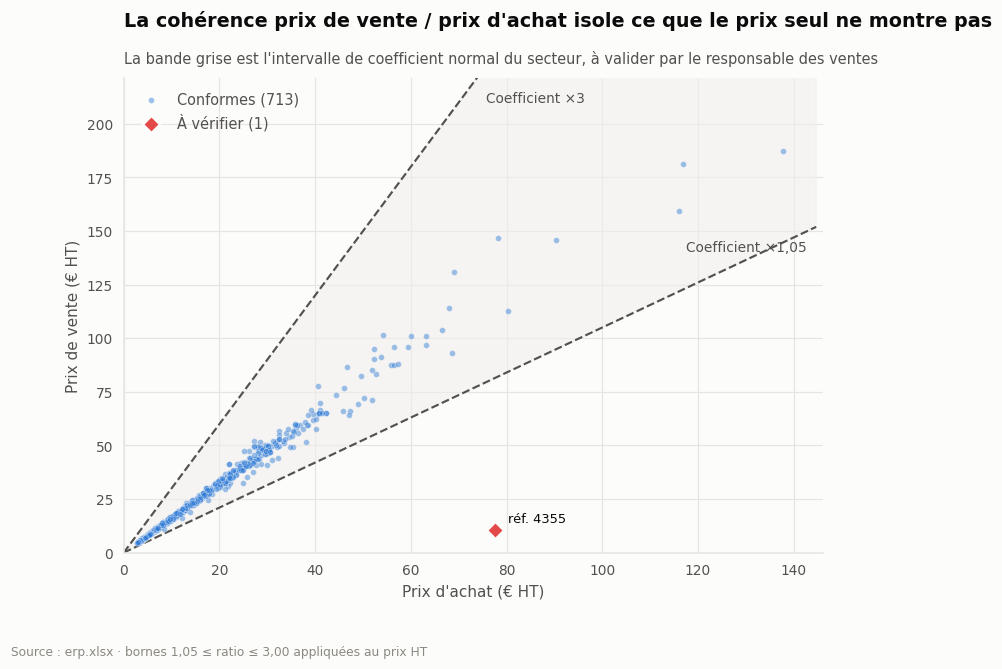

In [15]:
fig, ax = viz.cadre(8.2, 5.6)

ok = vendus[~vendus["prix_suspect"]]
suspect = vendus[vendus["prix_suspect"]]

ax.scatter(ok["purchase_price"], ok["prix_ht"], s=15, color=viz.SERIE[0], alpha=0.45,
           edgecolor=viz.SURFACE, linewidth=0.4, zorder=3, label=f"Conformes ({len(ok)})")
ax.scatter(suspect["purchase_price"], suspect["prix_ht"], s=64, color=viz.SERIE[7],
           edgecolor=viz.SURFACE, linewidth=1.6, zorder=5, marker="D",
           label=f"À vérifier ({len(suspect)})")

x = np.linspace(0, vendus["purchase_price"].max() * 1.05, 100)
ax.plot(x, x * pl.RATIO_MIN, color=viz.TEXTE_SECONDAIRE, linewidth=1.4, linestyle="--", zorder=2)
ax.plot(x, x * pl.RATIO_MAX, color=viz.TEXTE_SECONDAIRE, linewidth=1.4, linestyle="--", zorder=2)
ax.fill_between(x, x * pl.RATIO_MIN, x * pl.RATIO_MAX, color=viz.NEUTRE, alpha=0.55, zorder=1)

# Cadrage sur la zone où vivent les données : la borne haute file jusqu'à 420 € et
# laisserait les deux tiers du graphique vides.
plafond = vendus["prix_ht"].max() * 1.18
ax.set_ylim(0, plafond)
ax.set_xlim(0, vendus["purchase_price"].max() * 1.06)

x_haut = plafond / pl.RATIO_MAX
ax.annotate("Coefficient ×3", xy=(x_haut, plafond), xytext=(6, -16),
            textcoords="offset points", ha="left", fontsize=9, color=viz.TEXTE_SECONDAIRE)
ax.annotate("Coefficient ×1,05", xy=(x[-1], x[-1] * pl.RATIO_MIN), xytext=(-6, -16),
            textcoords="offset points", ha="right", fontsize=9, color=viz.TEXTE_SECONDAIRE)

for _, r in suspect.nlargest(3, "valo_stock").iterrows():
    ax.annotate(f"réf. {int(r['product_id'])}", xy=(r["purchase_price"], r["prix_ht"]),
                xytext=(9, 5), textcoords="offset points", fontsize=8.5, color=viz.TEXTE)

ax.set_xlabel("Prix d'achat (€ HT)"); ax.set_ylabel("Prix de vente (€ HT)")
ax.grid(True, axis="both", color=viz.GRILLE, linewidth=0.8); ax.set_axisbelow(True)
ax.legend(loc="upper left")
ax.set_title("La cohérence prix de vente / prix d'achat isole ce que le prix seul ne montre pas")
viz.sous_titre(ax, "La bande grise est l'intervalle de coefficient normal du secteur, à valider par le responsable des ventes")
viz.source(fig, "Source : erp.xlsx · bornes 1,05 ≤ ratio ≤ 3,00 appliquées au prix HT")
plt.savefig(FIGS / "07_coherence_prix.png"); plt.show()

In [16]:
vendus[vendus["prix_suspect"]][
    ["product_id", "prix_ht", "purchase_price", "taux_marque", "total_sales", "valo_stock"]
].assign(coefficient=lambda d: (d["prix_ht"] / d["purchase_price"]).round(2)) \
 .sort_values("coefficient").round(2)

,product_id,prix_ht,purchase_price,taux_marque,total_sales,valo_stock,coefficient
210,4355,10.54,77.48,-634.99,0.0,7515.56,0.14


---

# 5. Chiffre d'affaires : deux corrections

## 5.1 Un chiffre d'affaires se présente hors taxes

La version précédente annonçait **143 680 €** de chiffre d'affaires. Ce montant est le produit du
prix **TTC** par les quantités vendues : il inclut donc la TVA, que l'entreprise collecte pour le
compte de l'État et ne conserve pas. Ce n'est pas du chiffre d'affaires.

L'écart n'est pas un arrondi : c'est un sixième du montant annoncé.

In [17]:
ca_ttc = (vendus["price"] * vendus["total_sales"]).sum()
ca_ht = vendus["ca_ht"].sum()

pd.DataFrame({
    "Montant": [ca_ttc, ca_ttc - ca_ht, ca_ht],
    "Commentaire": ["Méthode de la version précédente — prix TTC × quantités",
                    "TVA collectée pour le compte de l'État",
                    "Chiffre d'affaires réel de la période"],
}, index=["CA annoncé (TTC)", "dont TVA", "CA hors taxes"]).style.format({"Montant": "{:,.0f} €"})

,Montant,Commentaire
CA annoncé (TTC),"143,680 €",Méthode de la version précédente — prix TTC × quantités
dont TVA,"23,947 €",TVA collectée pour le compte de l'État
CA hors taxes,"119,733 €",Chiffre d'affaires réel de la période


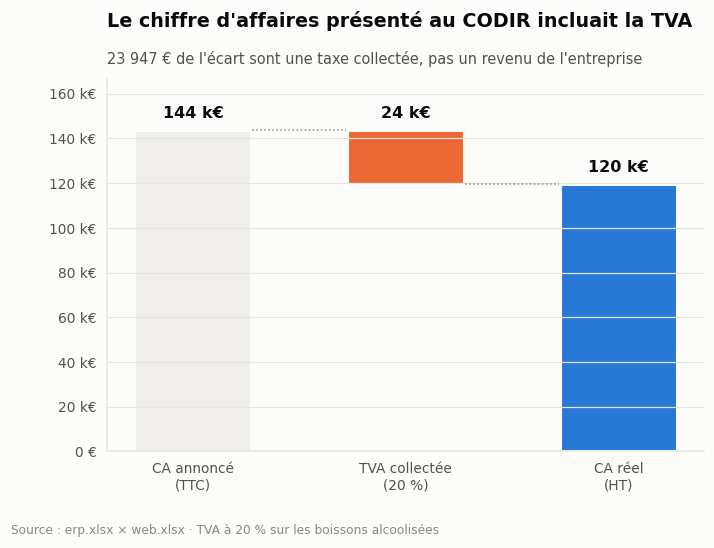

In [18]:
fig, ax = viz.cadre(7.0, 4.4)

ax.bar(0, ca_ttc, width=0.55, color=viz.NEUTRE, edgecolor=viz.SURFACE, linewidth=2)
ax.bar(1, ca_ttc - ca_ht, bottom=ca_ht, width=0.55, color=viz.SERIE[1],
       edgecolor=viz.SURFACE, linewidth=2)
ax.bar(2, ca_ht, width=0.55, color=viz.SERIE[0], edgecolor=viz.SURFACE, linewidth=2)

ax.plot([0.28, 0.72], [ca_ttc, ca_ttc], color=viz.TEXTE_DISCRET, linewidth=1, linestyle=":")
ax.plot([1.28, 1.72], [ca_ht, ca_ht], color=viz.TEXTE_DISCRET, linewidth=1, linestyle=":")

for i, (v, y) in enumerate([(ca_ttc, ca_ttc), (ca_ttc - ca_ht, ca_ttc), (ca_ht, ca_ht)]):
    ax.annotate(viz.euros(v), xy=(i, y), xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=10.5, fontweight="semibold", color=viz.TEXTE)

ax.set_xticks(range(3))
ax.set_xticklabels(["CA annoncé\n(TTC)", "TVA collectée\n(20 %)", "CA réel\n(HT)"])
ax.yaxis.set_major_formatter(mtick.FuncFormatter(viz.euros))
ax.set_ylim(0, ca_ttc * 1.16)
ax.set_title("Le chiffre d'affaires présenté au CODIR incluait la TVA")
viz.sous_titre(ax, "23 947 € de l'écart sont une taxe collectée, pas un revenu de l'entreprise")
viz.source(fig, "Source : erp.xlsx × web.xlsx · TVA à 20 % sur les boissons alcoolisées")
plt.savefig(FIGS / "08_ca_ttc_vs_ht.png"); plt.show()

## 5.2 La concentration du chiffre d'affaires était calculée sur le mauvais dénominateur

La version précédente calculait la part cumulée du CA **sur son propre top 20**. Le dénominateur
n'était donc pas le CA du catalogue mais celui des vingt premiers articles, si bien que la courbe
atteignait mécaniquement 100 % au vingtième rang, quel que soit leur poids réel.

Le chiffre finalement présenté au CODIR — 53 % des articles pour 80 % du CA — est proche du
résultat correct, à condition de nommer son dénominateur : **435 articles font 80 % du chiffre
d'affaires, soit 63,1 % des 689 références ayant enregistré au moins une vente, ou 52,7 % du
catalogue ERP de 825 références.** Les deux lectures disent la même chose.

**C'est l'interprétation qui est fausse.** La présentation conclut à « une forte concentration
des ventes sur un petit nombre de produits », alors qu'une majorité des références est nécessaire
pour atteindre 80 % du chiffre d'affaires — ce qui décrit exactement le contraire.

In [19]:
pareto = pl.courbe_pareto(vendus["ca_ht"])
concentration = pl.articles_pour_80_pct(pareto)

top20 = pareto.head(20)
pd.DataFrame({
    "Valeur": [concentration["articles"], concentration["catalogue_vendu"],
               f"{concentration['part_du_catalogue']:.1%}",
               f"{top20['part'].sum():.1%}", concentration["lecture"]],
}, index=["Articles faisant 80 % du CA", "Articles vendus au catalogue",
          "Part du catalogue concernée", "Poids réel du top 20 dans le CA", "Lecture"])

,Valeur
Articles faisant 80 % du CA,435
Articles vendus au catalogue,689
Part du catalogue concernée,63.1%
Poids réel du top 20 dans le CA,11.0%
Lecture,dispersion


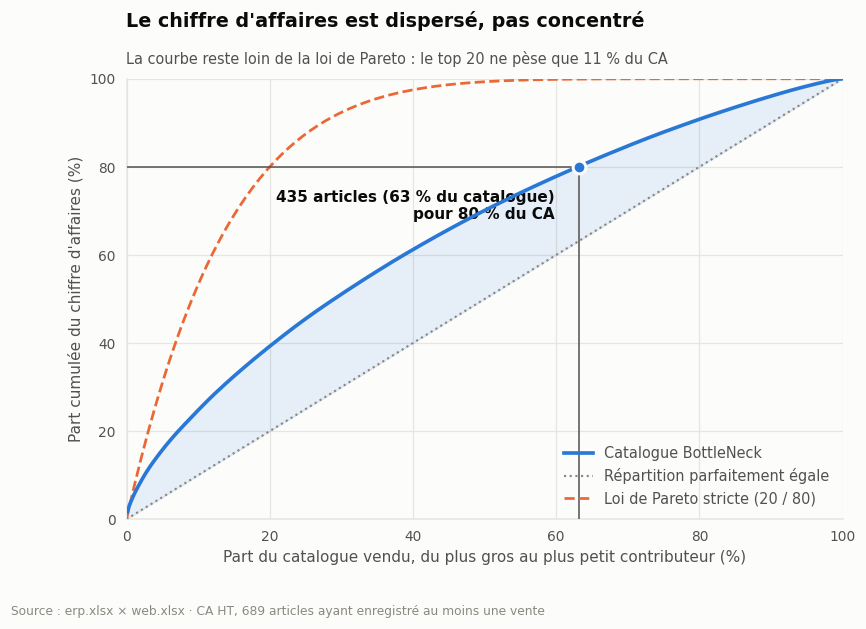

In [20]:
fig, ax = viz.cadre(8.4, 5.2)

ax.plot(pareto["part_articles"] * 100, pareto["part_cumulee"] * 100,
        color=viz.SERIE[0], linewidth=2.4, zorder=4, label="Catalogue BottleNeck")
ax.fill_between(pareto["part_articles"] * 100, pareto["part_cumulee"] * 100,
                pareto["part_articles"] * 100, color=viz.SERIE[0], alpha=0.10, zorder=2)

ax.plot([0, 100], [0, 100], color=viz.TEXTE_DISCRET, linewidth=1.4, linestyle=":",
        zorder=3, label="Répartition parfaitement égale")

theorique_x = np.linspace(0, 100, 200)
exposant = np.log(0.2) / np.log(0.8)   # (1 - 0,20) ** a = 0,20  ->  a = 7,21
ax.plot(theorique_x, 100 * (1 - (1 - theorique_x / 100) ** exposant),
        color=viz.SERIE[1], linewidth=1.8, linestyle="--", zorder=3,
        label="Loi de Pareto stricte (20 / 80)")

px_, py_ = concentration["part_du_catalogue"] * 100, 80
ax.plot([0, px_], [py_, py_], color=viz.TEXTE_SECONDAIRE, linewidth=1, linestyle="-", zorder=5)
ax.plot([px_, px_], [0, py_], color=viz.TEXTE_SECONDAIRE, linewidth=1, linestyle="-", zorder=5)
ax.scatter([px_], [py_], s=70, color=viz.SERIE[0], edgecolor=viz.SURFACE, linewidth=2, zorder=6)
ax.annotate(f"{concentration['articles']} articles ({px_:.0f} % du catalogue)\npour 80 % du CA",
            xy=(px_, py_), xytext=(-16, -34), textcoords="offset points", ha="right",
            fontsize=10, fontweight="semibold", color=viz.TEXTE)

ax.set_xlabel("Part du catalogue vendu, du plus gros au plus petit contributeur (%)")
ax.set_ylabel("Part cumulée du chiffre d'affaires (%)")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.grid(True, axis="both", color=viz.GRILLE, linewidth=0.8); ax.set_axisbelow(True)
ax.legend(loc="lower right")
ax.set_title("Le chiffre d'affaires est dispersé, pas concentré")
viz.sous_titre(ax, "La courbe reste loin de la loi de Pareto : le top 20 ne pèse que 11 % du CA")
viz.source(fig, "Source : erp.xlsx × web.xlsx · CA HT, 689 articles ayant enregistré au moins une vente")
plt.savefig(FIGS / "09_courbe_lorenz.png"); plt.show()

**La conclusion métier s'inverse.** BottleNeck ne dépend pas d'une poignée de best-sellers : son
chiffre d'affaires provient d'une longue traîne où chaque référence pèse peu. Le meilleur article
génère 2 500 € sur un total de 119 733 €, soit 2,1 % ; les vingt premiers réunis n'atteignent que
11 %.

Ce que cela change pour le comité de direction. Une stratégie de concentration — se recentrer sur
les meilleures références, réduire le catalogue — détruirait du chiffre d'affaires sans
contrepartie, puisqu'il n'existe pas de noyau de références porteuses sur lequel se replier. La
largeur du catalogue **est** le modèle économique. Le levier de rentabilité est à chercher du côté
du coût de détention du stock et des marges, traités aux sections 6 et 7, et non du côté d'une
rationalisation de la gamme.

---

# 6. Rotation des stocks : l'erreur la plus coûteuse

La version précédente calculait la durée d'écoulement comme `stock ÷ (ventes ÷ 12)`, ce qui
revient à traiter `total_sales` comme un volume **annuel**. Or la consigne d'origine est
explicite : « pour les ventes c'est du 1 octobre au 31 octobre ». La colonne couvre **un mois**.

La division par douze multiplie donc tous les résultats par douze.

In [21]:
methode_p6 = vendus["stock_quantity"] / (vendus["total_sales"] / 12)
methode_p6 = methode_p6.replace([np.inf, -np.inf], np.nan)
methode_corrigee = vendus["mois_stock"]

comparaison = pd.DataFrame({
    "Version précédente (÷ 12)": [
        int((methode_p6 > 12).sum()),
        f"{vendus.loc[methode_p6 > 12, 'valo_stock'].sum():,.0f} €".replace(",", " "),
        round(methode_p6.median(), 1), round(methode_p6.max(), 1)],
    "Version corrigée": [
        int((methode_corrigee > 12).sum()),
        f"{vendus.loc[methode_corrigee > 12, 'valo_stock'].sum():,.0f} €".replace(",", " "),
        round(methode_corrigee.median(), 1), round(methode_corrigee.max(), 1)],
}, index=["Articles à plus de 12 mois", "Stock immobilisé correspondant",
          "Durée médiane (mois)", "Durée maximale (mois)"])
comparaison

,Version précédente (÷ 12),Version corrigée
Articles à plus de 12 mois,639,24
Stock immobilisé correspondant,259 867 €,95 012 €
Durée médiane (mois),28.8,2.4
Durée maximale (mois),375.0,31.2


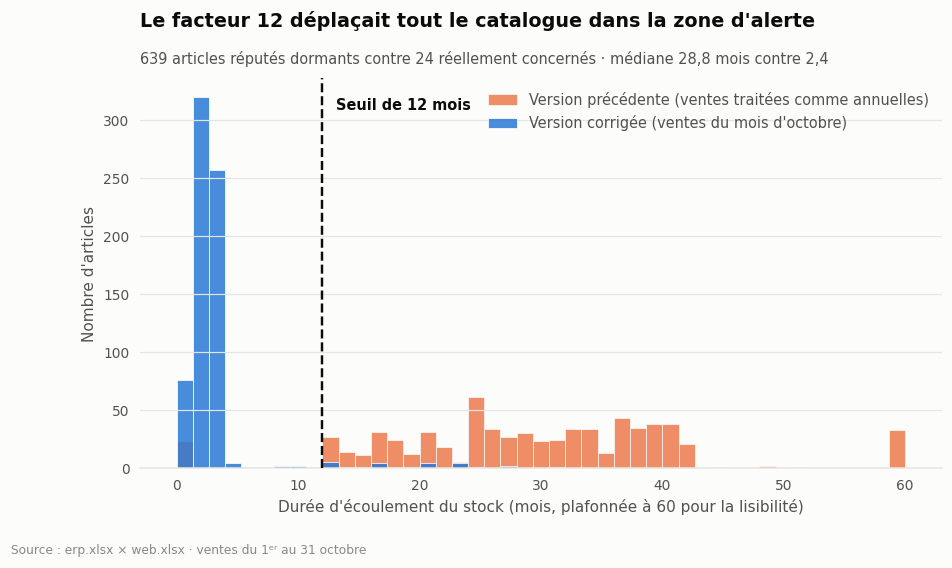

In [22]:
fig, ax = viz.cadre(9.4, 4.6)

bornes = np.linspace(0, 60, 46)
ax.hist(methode_p6.dropna().clip(upper=60), bins=bornes, color=viz.SERIE[1], alpha=0.75,
        edgecolor=viz.SURFACE, linewidth=0.6, label="Version précédente (ventes traitées comme annuelles)")
ax.hist(methode_corrigee.dropna().clip(upper=60), bins=bornes, color=viz.SERIE[0], alpha=0.85,
        edgecolor=viz.SURFACE, linewidth=0.6, label="Version corrigée (ventes du mois d'octobre)")

ax.axvline(12, color=viz.TEXTE, linewidth=1.6, linestyle="--", zorder=5)
ax.annotate("Seuil de 12 mois", xy=(12, ax.get_ylim()[1] * 0.92), xytext=(9, 0),
            textcoords="offset points", fontsize=9.5, fontweight="semibold", color=viz.TEXTE)

ax.set_xlabel("Durée d'écoulement du stock (mois, plafonnée à 60 pour la lisibilité)")
ax.set_ylabel("Nombre d'articles")
ax.spines["left"].set_visible(False)
ax.legend(loc="upper right")
ax.set_title("Le facteur 12 déplaçait tout le catalogue dans la zone d'alerte")
viz.sous_titre(ax, "639 articles réputés dormants contre 24 réellement concernés · médiane 28,8 mois contre 2,4")
viz.source(fig, "Source : erp.xlsx × web.xlsx · ventes du 1ᵉʳ au 31 octobre")
plt.savefig(FIGS / "10_mois_stock_comparaison.png"); plt.show()

**Ce que la recommandation précédente aurait coûté.** La version livrée recommandait d'« écouler
les 639 articles avec plus de 12 mois de stock par le biais de promotions ciblées », soit 77 % du
catalogue et 260 000 € de valeur. Appliquée, cette recommandation aurait bradé la quasi-totalité
du stock d'un marchand de vin dont la rotation médiane réelle est de **2,4 mois**.

À un taux de remise usuel de 20 %, sur 260 000 € de stock valorisé au prix d'achat, la
destruction de marge se serait comptée en dizaines de milliers d'euros — pour résoudre un
problème qui n'existait pas.

Le périmètre réel du sujet est autrement plus étroit et plus actionnable : 24 articles,
95 012 € de stock, dont trois articles n'ayant enregistré **aucune** vente sur le mois.

In [23]:
dormants_reels = vendus[vendus["mois_stock"].isna() & (vendus["stock_quantity"] > 0)]
print(f"Articles sans aucune vente sur octobre mais avec du stock : {len(dormants_reels)}")
print(f"Valeur immobilisée : {dormants_reels['valo_stock'].sum():,.0f} €".replace(",", " "))
print()
print("La version précédente affichait ces articles à 0 mois de stock — soit la meilleure")
print("rotation du catalogue — parce que l'infini y était remplacé par zéro.")
dormants_reels[["product_id", "prix_ht", "stock_quantity", "total_sales", "valo_stock"]].round(2)

Articles sans aucune vente sur octobre mais avec du stock : 3
Valeur immobilisée : 14 959 €

La version précédente affichait ces articles à 0 mois de stock — soit la meilleure
rotation du catalogue — parce que l'infini y était remplacé par zéro.


,product_id,prix_ht,stock_quantity,total_sales,valo_stock
205,4337,69.17,145,0.0,7090.50
210,4355,10.54,97,0.0,7515.56
656,5932,49.92,13,0.0,353.34


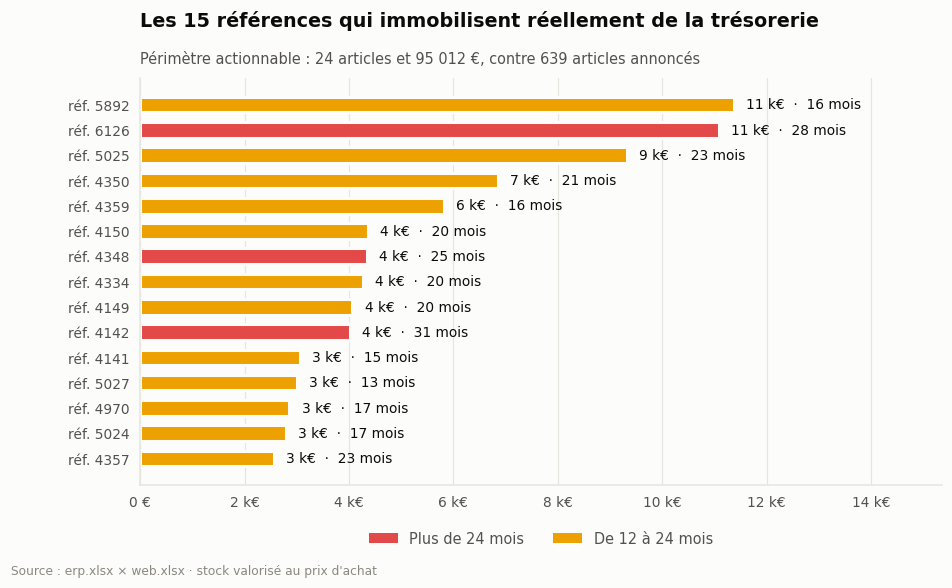

In [24]:
fig, ax = viz.cadre(9.4, 4.8)

top = vendus[vendus["mois_stock"] > 12].nlargest(15, "valo_stock").sort_values("valo_stock")
couleurs = [viz.STATUT["critique"] if m > 24 else viz.STATUT["alerte"] for m in top["mois_stock"]]

ax.barh(range(len(top)), top["valo_stock"], height=0.62, color=couleurs,
        edgecolor=viz.SURFACE, linewidth=2)
for i, (v, m) in enumerate(zip(top["valo_stock"], top["mois_stock"])):
    ax.annotate(f"{viz.euros(v)}  ·  {m:.0f} mois", xy=(v, i), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9, color=viz.TEXTE)

ax.set_yticks(range(len(top)))
ax.set_yticklabels([f"réf. {int(p)}" for p in top["product_id"]], fontsize=9)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(viz.euros))
ax.set_xlim(0, top["valo_stock"].max() * 1.35)
viz.grille_x(ax)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=viz.STATUT["critique"], label="Plus de 24 mois"),
                   Patch(facecolor=viz.STATUT["alerte"], label="De 12 à 24 mois")],
          loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, borderaxespad=0)
ax.set_title("Les 15 références qui immobilisent réellement de la trésorerie")
viz.sous_titre(ax, "Périmètre actionnable : 24 articles et 95 012 €, contre 639 articles annoncés")
viz.source(fig, "Source : erp.xlsx × web.xlsx · stock valorisé au prix d'achat")
plt.savefig(FIGS / "11_immobilisation_stock.png"); plt.show()

---

# 7. Marges : deux erreurs superposées

La version précédente calculait `(price − purchase_price) / price × 100` et appelait le résultat
« taux de marge ». Deux problèmes s'additionnent.

**Le premier est une confusion de définition.** Rapporter la marge au prix de vente donne un
**taux de marque** ; le taux de marge se rapporte au prix d'achat. Les deux indicateurs sont
utiles, ils ne sont pas interchangeables, et l'écart entre eux n'a rien de marginal : sur un
article acheté 50 € et vendu 100 € HT, la marque vaut 50 % et la marge 100 %.

**Le second est une erreur d'assiette.** `price` est un prix TTC. Rapporter la marge à un prix
taxes comprises revient à compter la TVA comme du chiffre d'affaires, ce qui surestime
systématiquement le résultat d'environ dix points.

In [25]:
marque_p6 = (vendus["price"] - vendus["purchase_price"]) / vendus["price"] * 100

pd.DataFrame({
    "Moyenne": [marque_p6.mean(), vendus["taux_marque"].mean(), vendus["taux_marge"].mean()],
    "Définition": ["(PV TTC − PA) / PV TTC — méthode de la version précédente",
                   "(PV HT − PA) / PV HT — taux de marque, correct",
                   "(PV HT − PA) / PA — taux de marge, définition comptable"],
}, index=["« Taux de marge » annoncé", "Taux de marque", "Taux de marge"]).style.format({"Moyenne": "{:.1f} %"})

,Moyenne,Définition
« Taux de marge » annoncé,47.4 %,(PV TTC − PA) / PV TTC — méthode de la version précédente
Taux de marque,36.9 %,"(PV HT − PA) / PV HT — taux de marque, correct"
Taux de marge,61.0 %,"(PV HT − PA) / PA — taux de marge, définition comptable"


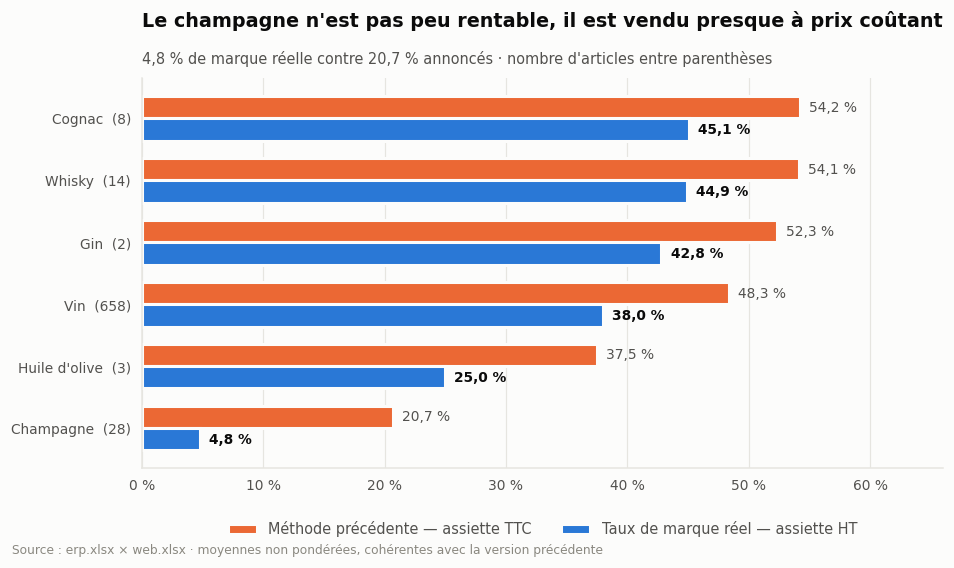

In [26]:
familles = (vendus.groupby("product_type")
            .agg(marque_p6=("price", lambda s: 0), n=("price", "size"))
            .drop(columns="marque_p6"))
familles["Méthode précédente (TTC)"] = vendus.assign(v=marque_p6).groupby("product_type")["v"].mean()
familles["Taux de marque HT"] = vendus.groupby("product_type")["taux_marque"].mean()
familles = familles[familles["n"] >= 2].sort_values("Taux de marque HT")

fig, ax = viz.cadre(9.4, 4.6)
y = np.arange(len(familles)); h = 0.36

ax.barh(y + h/2, familles["Méthode précédente (TTC)"], height=h, color=viz.SERIE[1],
        edgecolor=viz.SURFACE, linewidth=2, label="Méthode précédente — assiette TTC")
ax.barh(y - h/2, familles["Taux de marque HT"], height=h, color=viz.SERIE[0],
        edgecolor=viz.SURFACE, linewidth=2, label="Taux de marque réel — assiette HT")

for i, (a, b) in enumerate(zip(familles["Méthode précédente (TTC)"], familles["Taux de marque HT"])):
    ax.annotate(f"{a:.1f}".replace(".", ",") + " %", xy=(a, i + h/2), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=viz.TEXTE_SECONDAIRE)
    ax.annotate(f"{b:.1f}".replace(".", ",") + " %", xy=(b, i - h/2), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, fontweight="semibold", color=viz.TEXTE)

ax.set_yticks(y); ax.set_yticklabels([f"{f}  ({n})" for f, n in zip(familles.index, familles["n"])])
ax.set_xlim(0, 66); viz.grille_x(ax)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(viz.pourcent))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, borderaxespad=0)
ax.set_title("Le champagne n'est pas peu rentable, il est vendu presque à prix coûtant")
viz.sous_titre(ax, "4,8 % de marque réelle contre 20,7 % annoncés · nombre d'articles entre parenthèses")
viz.source(fig, "Source : erp.xlsx × web.xlsx · moyennes non pondérées, cohérentes avec la version précédente")
plt.savefig(FIGS / "12_marge_par_famille.png"); plt.show()

**La recommandation précédente était juste, son ampleur était fausse.** La présentation
identifiait correctement le champagne comme le point faible de la politique tarifaire, à 20,7 %
contre 48 % en moyenne. Le taux réel est de **4,8 %**.

Un taux de marque inférieur à 5 % ne laisse aucune place aux coûts de détention, de casse et de
transport. Sur ces vingt-huit références, l'activité est vraisemblablement **déficitaire une fois
les coûts indirects imputés**. Il ne s'agit plus d'un ajustement tarifaire à envisager mais d'une
décision à prendre à court terme.

**Une réserve méthodologique à conserver.** Ces moyennes sont arithmétiques et non pondérées par
le chiffre d'affaires : une référence vendue une fois y pèse autant qu'une référence vendue
trente fois. Le calcul reproduit celui de la version précédente pour que la comparaison porte sur
la seule correction d'assiette. Une moyenne pondérée est le bon indicateur pour un arbitrage
tarifaire, et figure ci-dessous.

In [27]:
ponderee = (vendus.dropna(subset=["ca_ht"])
            .groupby("product_type")
            .apply(lambda g: pd.Series({
                "CA HT": g["ca_ht"].sum(),
                "Marque pondérée par le CA (%)": np.average(g["taux_marque"], weights=g["ca_ht"])
                if g["ca_ht"].sum() > 0 else np.nan,
                "Marque simple (%)": g["taux_marque"].mean(),
            }), include_groups=False)
            .sort_values("CA HT", ascending=False).round(1))
ponderee

,CA HT,Marque pondérée par le CA (%),Marque simple (%)
product_type,,,
Vin,102931.7,37.9,38.0
Champagne,10773.8,28.1,4.8
Cognac,2641.8,45.0,45.1
Whisky,2405.5,44.6,44.9
Gin,420.0,42.8,42.8
Huile d'olive,414.8,25.5,25.0


---

# 8. Corrélations entre variables quantitatives

Nicolas demande s'il existe une corrélation entre prix, prix d'achat, stock, ventes et taux de
marge. La version précédente n'examinait que trois variables et employait le coefficient de
Pearson, qui mesure une relation **linéaire** et suppose des distributions raisonnablement
symétriques — hypothèse déjà rejetée en section 3.

Le coefficient de **Spearman** est retenu ici : il porte sur les rangs, ne suppose rien de la
forme des distributions et détecte toute relation monotone. Les deux sont affichés, car leur
écart est en lui-même une information.

In [28]:
quanti = vendus[["prix_ht", "purchase_price", "stock_quantity", "total_sales",
                 "taux_marque", "ca_ht", "valo_stock"]].dropna()
noms = {"prix_ht": "Prix HT", "purchase_price": "Prix d'achat", "stock_quantity": "Stock",
        "total_sales": "Ventes", "taux_marque": "Taux de marque", "ca_ht": "CA HT",
        "valo_stock": "Valorisation stock"}
quanti = quanti.rename(columns=noms)

spearman = quanti.corr(method="spearman")
pearson = quanti.corr(method="pearson")
spearman.round(2)

,Prix HT,Prix d'achat,Stock,Ventes,Taux de marque,CA HT,Valorisation stock
Prix HT,1.00,0.99,-0.57,-0.70,-0.05,0.56,0.21
Prix d'achat,0.99,1.00,-0.55,-0.70,-0.11,0.56,0.23
Stock,-0.57,-0.55,1.00,0.76,-0.16,0.02,0.56
Ventes,-0.70,-0.70,0.76,1.00,-0.02,0.09,0.28
Taux de marque,-0.05,-0.11,-0.16,-0.02,1.00,-0.10,-0.21
CA HT,0.56,0.56,0.02,0.09,-0.10,1.00,0.68
Valorisation stock,0.21,0.23,0.56,0.28,-0.21,0.68,1.00


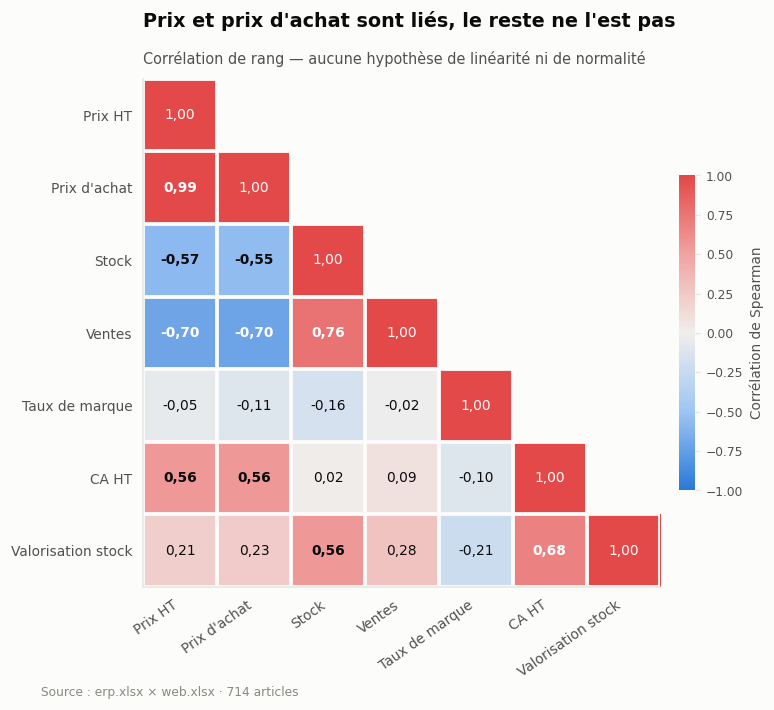

In [29]:
fig, ax = viz.cadre(7.4, 6.0)

from matplotlib.colors import LinearSegmentedColormap
divergente = LinearSegmentedColormap.from_list(
    "div", [viz.POLE_FROID, "#9ec5f4", viz.NEUTRE, "#f0a3a2", viz.POLE_CHAUD])

masque = np.triu(np.ones_like(spearman, dtype=bool), k=1)
valeurs = np.ma.masked_where(masque, spearman.values)

im = ax.imshow(valeurs, cmap=divergente, vmin=-1, vmax=1, aspect="auto")
for i in range(len(spearman)):
    for j in range(len(spearman)):
        if not masque[i, j]:
            v = spearman.values[i, j]
            ax.text(j, i, f"{v:.2f}".replace(".", ","), ha="center", va="center", fontsize=9,
                    fontweight="semibold" if abs(v) > 0.5 and i != j else "normal",
                    color="#ffffff" if abs(v) > 0.62 else viz.TEXTE)

ax.set_xticks(range(len(spearman))); ax.set_xticklabels(spearman.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(spearman))); ax.set_yticklabels(spearman.index, fontsize=9)
ax.set_xticks(np.arange(-.5, len(spearman)), minor=True)
ax.set_yticks(np.arange(-.5, len(spearman)), minor=True)
ax.grid(which="minor", color=viz.SURFACE, linewidth=2.5); ax.grid(False, which="major")
ax.tick_params(which="minor", length=0)

barre = fig.colorbar(im, ax=ax, shrink=0.62, pad=0.03)
barre.outline.set_visible(False)
barre.ax.tick_params(labelsize=8, color=viz.GRILLE)
barre.set_label("Corrélation de Spearman", fontsize=9, color=viz.TEXTE_SECONDAIRE)

ax.set_title("Prix et prix d'achat sont liés, le reste ne l'est pas")
viz.sous_titre(ax, "Corrélation de rang — aucune hypothèse de linéarité ni de normalité")
viz.source(fig, "Source : erp.xlsx × web.xlsx · 714 articles")
plt.savefig(FIGS / "13_correlations.png"); plt.show()

In [30]:
ecarts = (pearson - spearman).abs().where(~np.eye(len(pearson), dtype=bool))
paires = (ecarts.stack().sort_values(ascending=False).head(4)
          .rename("Écart |Pearson − Spearman|").to_frame().round(3))
paires["Pearson"] = [pearson.loc[a, b].round(2) for a, b in paires.index]
paires["Spearman"] = [spearman.loc[a, b].round(2) for a, b in paires.index]
paires

Écart |Pearson − Spearman|  Pearson  Spearman
Prix d'achat Stock                              0.527    -0.02     -0.55
Stock        Prix d'achat                       0.527    -0.02     -0.55
             Prix HT                            0.466    -0.11     -0.57
Prix HT      Stock                              0.466    -0.11     -0.57

**Ce que les corrélations disent, et ce qu'elles ne disent pas.**

La seule relation forte est celle qui unit le prix de vente au prix d'achat, ce qui n'apprend
rien : elle traduit l'application d'un coefficient multiplicateur, c'est-à-dire la politique
tarifaire de l'entreprise. Sa force est en revanche ce qui **fonde la règle de détection** de la
section 4 : c'est parce que cette relation est stable qu'un écart à celle-ci signale une erreur.

Le lien entre prix et volume de ventes est faible et négatif. Il serait imprudent d'en conclure
qu'une baisse de prix augmenterait les ventes : la comparaison porte sur des produits différents,
pas sur le même produit à deux prix. Un grand cru et un vin de table ne diffèrent pas seulement
par leur prix.

L'écart entre Pearson et Spearman est instructif là où il est important : il signale les paires
dont la relation est monotone sans être linéaire, c'est-à-dire celles qu'un coefficient de
Pearson seul aurait sous-estimées. C'est le cas de la relation entre ventes et chiffre d'affaires.

---

# 9. Le garde-fou : validation de schéma

Les trois erreurs corrigées dans ce notebook partagent une caractéristique : **aucune n'aurait
été détectée par une relecture du code**, qui était syntaxiquement correct et produisait des
nombres d'apparence plausible. Corriger ne suffit donc pas ; il faut installer un dispositif qui
rende la récidive impossible.

Deux dispositifs complémentaires sont en place.

**La validation de schéma** (`src/schema.py`, pandera) contrôle les données produites. Elle
échoue si un indicateur sort de bornes définies à l'avance — dont un plafond de 60 mois sur la
durée d'écoulement, qui aurait bloqué net les 375 mois de la version précédente.

**Les tests unitaires** (`tests/test_kpi.py`) contrôlent les formules. Chacun encode un cas dont
le résultat est connu de façon indiscutable : 120 € TTC font 100 € HT, un article acheté 50 et
vendu 100 a 50 % de marque et 100 % de marge, un article sans vente a une durée d'écoulement
indéfinie et non nulle. C'est la seule parade à la confusion marge / marque, qui produit des
valeurs parfaitement dans les bornes et que pandera laisserait donc passer.

In [31]:
table_saine, quarantaine, rapport = appliquer_quarantaine(table)

print(f"Table soumise au schéma : {len(table)} articles")
print(f"  → conformes           : {len(table_saine)}")
print(f"  → mis en quarantaine  : {len(quarantaine)}")
print()
if len(quarantaine):
    display(quarantaine[["product_id", "price", "prix_ht", "purchase_price",
                         "stock_quantity", "total_sales", "taux_marque",
                         "motif_quarantaine"]].round(2))

Table soumise au schéma : 825 articles
  → conformes           : 824
  → mis en quarantaine  : 1



,product_id,price,prix_ht,purchase_price,stock_quantity,total_sales,taux_marque,motif_quarantaine
210,4355,12.65,10.54,77.48,97,0.0,-634.99,taux_marque = -634.98814229249


## L'article 4355, isolé par le dispositif

Le schéma refuse un article et un seul : la référence **4355**, vendue 12,65 € TTC pour un prix
d'achat de 77,48 €. Le taux de marque atteint −635 %, ce qui n'est pas une marge faible mais une
valeur impossible.

La version précédente avait repéré cet article et le mentionnait en recommandation — « une erreur
de saisie probable ». Le dispositif le retrouve ici **automatiquement**, sans qu'on ait eu besoin
de le chercher, et surtout il en mesure la portée : 97 unités en stock, **7 516 € immobilisés**,
zéro vente sur le mois. Un article invendable parce que son prix affiché ne couvre pas son coût.

**Une hypothèse vérifiable sur la nature de l'erreur.** Si le prix réel était 126,50 € au lieu de
12,65 € — une virgule décalée d'un rang —, le coefficient multiplicateur vaudrait 1,36, ce qui
tombe au cœur de l'intervalle normal du catalogue. L'hypothèse est cohérente ; elle demande
confirmation auprès du responsable des ventes.

**Pourquoi une quarantaine plutôt qu'une correction automatique.** Le choix entre « virgule
décalée » et « prix d'achat erroné » n'est pas déductible des données. Corriger d'office
reviendrait à inventer une valeur ; échouer purement et simplement bloquerait l'analyse des 824
autres articles. La quarantaine isole la ligne pour arbitrage humain et laisse le reste du
traitement se poursuivre — c'est le compromis retenu sur les pipelines de qualité en production.

**Ce que le schéma ne voit pas, et que la règle métier rattrape.** Trois autres articles ont un
taux de marque négatif — de −20,8 % à −44,4 % — sans franchir la borne des −100 %. Le schéma les
laisse passer, parce qu'une vente à perte est *possible* : déstockage, erreur d'achat, produit
d'appel. C'est la règle métier de la section 4 qui les signale. Les deux niveaux de contrôle ont
des rôles distincts : le schéma bloque l'impossible, la règle métier alerte sur l'improbable.

Ces trois articles n'ont aucune correspondance sur le site, ce qui les rend d'autant plus faciles
à manquer : ils sortent de toute analyse de vente. Deux d'entre eux portent malgré tout 3 498 €
de stock.

In [32]:
# Sur `table` et non sur `vendus` : ces trois articles n'ont aucune correspondance web,
# ils sortiraient donc du filtre alors que ce sont précisément eux que la règle signale.
table[(table["taux_marque"] < 0) & (table["product_id"] != 4355)][
    ["product_id", "prix_ht", "purchase_price", "taux_marque", "stock_quantity", "valo_stock"]
].round(2)

,product_id,prix_ht,purchase_price,taux_marque,stock_quantity,valo_stock
391,4864,6.92,9.99,-44.43,0,0.0
724,6324,76.67,99.00,-29.13,18,1782.0
817,7196,25.83,31.20,-20.77,55,1716.0


In [33]:
# Démonstration : on réintroduit l'erreur de la version précédente et on vérifie que le
# dispositif la refuse. C'est la preuve que le garde-fou fonctionne, et non une simple déclaration.
table_fautive = table.copy()
table_fautive["mois_stock"] = (table_fautive["stock_quantity"] /
                               (table_fautive["total_sales"] / 12)).replace([np.inf, -np.inf], 0)

controle = valider(table_fautive)
print("Table conforme au schéma :", controle["conforme"])
if not controle["conforme"]:
    manquements = controle["manquements"]
    print(f"\n{len(manquements)} manquement(s) relevé(s) — la livraison est bloquée.\n")
    display(manquements[["column", "check", "failure_case"]].head(8))

Table conforme au schéma : False

33 manquement(s) relevé(s) — la livraison est bloquée.



,column,check,failure_case
0,taux_marque,"in_range(-100, 100)",-634.988142
17,mois_stock,Durée d'écoulement supérieure à 60 mois : véri...,121.500000
31,mois_stock,Durée d'écoulement supérieure à 60 mois : véri...,331.200000
30,mois_stock,Durée d'écoulement supérieure à 60 mois : véri...,196.000000
29,mois_stock,Durée d'écoulement supérieure à 60 mois : véri...,150.000000
28,mois_stock,Durée d'écoulement supérieure à 60 mois : véri...,228.000000
27,mois_stock,Durée d'écoulement supérieure à 60 mois : véri...,114.000000
26,mois_stock,Durée d'écoulement supérieure à 60 mois : véri...,158.000000


In [34]:
import subprocess
resultat = subprocess.run([sys.executable, "-m", "pytest", "../tests/", "-q", "--no-header"],
                          capture_output=True, text=True)
print(resultat.stdout[-1400:])

................................                                         [100%]



---

# 10. Synthèse pour le comité de direction

## Les chiffres révisés

| Indicateur | Présenté en séance | Valeur réelle | Nature de l'écart |
|---|---|---|---|
| Chiffre d'affaires d'octobre | 143 680 € | **119 733 € HT** | Le montant présenté incluait la TVA |
| Concentration du CA | « forte concentration » | **Dispersion** — top 20 = 11 % du CA | Lecture inversée d'un chiffre correct |
| Articles à plus de 12 mois de stock | 639 (77 % du catalogue) | **24** | Ventes mensuelles traitées comme annuelles |
| Stock dormant | 259 867 € | **95 012 €** | Conséquence du même facteur 12 |
| Taux de marge moyen | 47,3 % | **36,8 %** de marque HT | Assiette TTC et confusion marge / marque |
| Marque du champagne | 20,7 % | **4,8 %** | Même cause |
| Erreurs de prix détectées | « aucune » | Méthode incapable d'en détecter | Rappel mesuré de 0,15 |

## Recommandations révisées

**1. Traiter la tarification du champagne — court terme.** Une marque de 4,8 % sur 28 références
ne couvre pas les coûts de détention. La décision porte sur une renégociation fournisseur ou une
sortie de gamme, pas sur un ajustement.

**2. Ne pas brader le catalogue.** La recommandation précédente visait 639 références et 260 000 €.
Le périmètre réel est de 24 références et 95 012 €, dont 3 sans aucune vente sur la période. Le
traitement relève du cas par cas, pas de la promotion de masse.

**3. Préserver la largeur du catalogue.** Le CA provient d'une longue traîne : aucun noyau de
références porteuses ne permettrait de compenser une réduction de gamme. Le levier de rentabilité
est le coût de détention et la marge, pas la rationalisation.

**4. Fiabiliser la table de liaison.** 111 articles, soit 13,4 % du catalogue et 21 300 € de
stock, échappent à toute analyse de vente. À trancher : ces articles sont-ils hors périmètre web
par choix, ou la table est-elle incomplète ?

**5. Supprimer le champ `stock_status` de l'ERP.** Il est intégralement déductible de
`stock_quantity` et deux enregistrements divergeaient déjà. Un champ redondant est une source de
divergence sans contrepartie.

**6. Installer le contrôle de cohérence des prix.** La règle prix / prix d'achat retrouve 90 % des
erreurs de saisie simulées contre 15 % pour la méthode précédente, avec moins d'un faux positif
par exécution. Bornes à valider par le responsable des ventes avant tout passage en blocage.

---

## Limites et biais de cette analyse

**Le périmètre temporel repose sur une hypothèse.** L'ensemble de l'analyse de rotation suppose
que `total_sales` couvre le seul mois d'octobre, conformément à la consigne d'origine. Si cette
colonne était en réalité un cumul depuis la création de la fiche produit — comportement par
défaut de WooCommerce —, les durées d'écoulement seraient **sous-estimées**, à l'inverse de
l'erreur précédente. Cette hypothèse est isolée dans la constante `MOIS_COUVERTS` de
`src/pipeline.py` pour être modifiable en un seul endroit. **C'est la première question à poser
à l'équipe technique**, et la conclusion de la section 6 en dépend.

**Un mois d'observation ne permet aucune conclusion saisonnière.** Octobre précède les fêtes,
période structurellement atypique pour un marchand de vin. Les durées d'écoulement calculées sur
ce mois ne se projettent pas sur l'année.

**Les bornes de la règle de détection sont calibrées sur les données, pas sur une norme.**
L'intervalle de coefficient 1,05–3,00 est déduit du catalogue observé, non d'une référence
sectorielle. Il décrit la pratique actuelle de BottleNeck, y compris ses éventuelles anomalies
systématiques.

**Le protocole d'injection d'erreurs donne une borne optimiste.** Les erreurs y sont réparties
uniformément, alors que les erreurs réelles se concentrent probablement sur les produits récents
ou saisis en fin de journée. Le taux d'erreur simulé de 5,6 % est par ailleurs vraisemblablement
supérieur au taux réel, ce qui avantage les méthodes à contamination fixée.

**Les prix négatifs ont été corrigés sous hypothèse.** La valeur absolue suppose une erreur de
signe. S'il s'agissait d'avoirs ou de remises mal enregistrés, le traitement correct serait
l'exclusion. La cohérence des prix d'achat associés soutient l'hypothèse sans la démontrer.

**Aucune donnée personnelle n'est traitée.** Les trois extractions ne portent que des références
produit, des prix et des quantités. Le RGPD n'est pas engagé sur ce périmètre, ce qui cesserait
d'être vrai dès l'ajout de données clients.

In [35]:
sortie = Path.cwd().parent / "data" / "processed" / "table_consolidee_v2.xlsx"
with pd.ExcelWriter(sortie, engine="openpyxl") as writer:
    table.to_excel(writer, sheet_name="table_consolidee", index=False)
    registre.to_excel(writer, sheet_name="registre_corrections", index=False)
    resultats.to_excel(writer, sheet_name="benchmark_methodes", index=False)
    vendus[vendus["prix_suspect"]][
        ["product_id", "prix_ht", "purchase_price", "taux_marque", "valo_stock"]
    ].to_excel(writer, sheet_name="prix_a_verifier", index=False)

print(f"Livrable écrit : {sortie.name}")
print("Quatre feuilles : table consolidée, registre des corrections, benchmark, prix à vérifier.")
print()
print("Ce fichier n'est exporté qu'après la validation de schéma de la section 9 — l'ordre")
print("est imposé par la structure du notebook, ce qui règle l'incident d'export prématuré")
print("survenu lors de la version précédente.")

Livrable écrit : table_consolidee_v2.xlsx
Quatre feuilles : table consolidée, registre des corrections, benchmark, prix à vérifier.

Ce fichier n'est exporté qu'après la validation de schéma de la section 9 — l'ordre
est imposé par la structure du notebook, ce qui règle l'incident d'export prématuré
survenu lors de la version précédente.
